In [ ]:
# Download the GTEx sex-biased genes file (Marouen's task)
!curl -O https://storage.googleapis.com/gtex_analysis_v8/single_tissue_qtl_data/GTEx_Analysis_v8_sbgenes.tar.gz

# Check if it downloaded (and file size)
!ls -lh GTEx_Analysis_v8_sbgenes.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   233  100   233    0     0    332      0 --:--:-- --:--:-- --:--:--   332
-rw-r--r-- 1 root root 233 May 29 05:18 GTEx_Analysis_v8_sbgenes.tar.gz


### Cell 1 - Trying to download the data
**What we do:** We use `curl` (a tool that downloads files from the internet) to grab the GTEx sex-biased genes file, then use `ls -lh` to list the file and show its size.

**Output:** The file saved, but it is only **233 bytes** - far too small for real data.

**Why it matters:** A real data file would be many megabytes. This tiny size is a warning sign that the download did **not** actually work (the web address was wrong).

*Jargon:* `curl` = download-from-internet command. `ls -lh` = list files in human-readable sizes. A *byte* is a tiny unit of computer storage; 233 bytes is only about two sentences of text.

In [ ]:
!ls -lh GTEx_Analysis_v8_sbgenes.tar.g

ls: cannot access 'GTEx_Analysis_v8_sbgenes.tar.g': No such file or directory


### Cell 2 - A typo while checking the file
**What we do:** We try `ls -lh` again, but the filename is misspelled - it ends in `.tar.g` instead of `.tar.gz` (the `z` is missing).

**Output:** An error: "cannot access ... No such file or directory."

**Why it matters:** The computer looks for the exact name we type. Because the name was wrong by one letter, it could not find the file. This was just a small typo, not a real problem with the data.

*Jargon:* A *typo* is a small spelling mistake. File names must match exactly, including the ending like `.gz`.

In [ ]:
!ls -lh

total 12K
drwx------ 5 root root 4.0K May 29 04:48 drive
-rw-r--r-- 1 root root  233 May 29 05:18 GTEx_Analysis_v8_sbgenes.tar.gz
drwxr-xr-x 1 root root 4.0K May 26 13:25 sample_data


### Cell 3 - Listing everything in the folder
**What we do:** We run `ls -lh` with no filename, so it lists **all** files and folders in the current location.

**Output:** It shows the `drive` folder, the tiny 233-byte file, and the `sample_data` folder.

**Why it matters:** This confirms the bad 233-byte file is still there, and lets us see what else is around - like opening a drawer to see everything inside.

### Cell 4 - Opening the file to see what went wrong

**What we do:** Instead of guessing, we open the downloaded file and print its contents, so we can read exactly what is inside it.

**Output:** It shows an XML error message containing `NoSuchKey` and "The specified key does not exist."

**Why it matters:** This confirms the download failed. The server did not have a file at that web address, so it sent back a short error page instead of real data - and that error page is what got saved.

*Jargon:* `open(...).read()` opens a file and reads its text. `NoSuchKey` is a storage server's way of saying "there is no file at this address."

In [ ]:
# Check what was actually downloaded
print(open('GTEx_Analysis_v8_sbgenes.tar.gz').read())

<?xml version='1.0' encoding='UTF-8'?><Error><Code>NoSuchKey</Code><Message>The specified key does not exist.</Message><Details>No such object: gtex_analysis_v8/single_tissue_qtl_data/GTEx_Analysis_v8_sbgenes.tar.gz</Details></Error>


### Cell 5 - Deleting the bad file

**What we do:** We use `rm` to delete the broken 233-byte file, then list the folder again with `ls -lh` to confirm it is gone.

**Output:** The folder now shows only the `drive` and `sample_data` folders - the bad file is no longer there.

**Why it matters:** There is no point keeping a file that only holds an error message. Removing it keeps the workspace clean before we try to get the real data a different way.

*Jargon:* `rm` = remove (delete) a file.

In [ ]:
!rm GTEx_Analysis_v8_sbgenes.tar.gz
!ls -lh

total 8.0K
drwx------ 5 root root 4.0K May 29 04:48 drive
drwxr-xr-x 1 root root 4.0K May 26 13:25 sample_data


### Cell 6 - Trying to copy the file from Google Drive

**What we do:** We try a different source: copy the data file from a Google Drive folder into our workspace using `cp`, then check it with `ls -lh`.

**Output:** Two errors - `cannot stat ... No such file or directory` and `cannot access ...` - meaning the file was not found in Drive either.

**Why it matters:** This was a backup plan to get the data, but the file is not sitting in that Drive folder, so this approach also did not work. We will have to upload it manually next.

*Jargon:* `cp` = copy a file. `cannot stat` is the system saying it cannot find the file you asked about.

In [ ]:
!cp "/content/drive/MyDrive/GTEx_Analysis_v8_sbgenes.tar.gz" .
!ls -lh GTEx_Analysis_v8_sbgenes.tar.gz

cp: cannot stat '/content/drive/MyDrive/GTEx_Analysis_v8_sbgenes.tar.gz': No such file or directory
ls: cannot access 'GTEx_Analysis_v8_sbgenes.tar.gz': No such file or directory


### Cell 7 - Checking once more if the file exists

**What we do:** We run `ls -lh` on the data file name again to double-check whether it is present.

**Output:** `cannot access ... No such file or directory` - the file is still not there.

**Why it matters:** This confirms that none of the automatic download or copy attempts worked. The only reliable option left is to upload the file by hand, which we do in the next step.

In [ ]:
!ls -lh GTEx_Analysis_v8_sbgenes.tar.gz

ls: cannot access 'GTEx_Analysis_v8_sbgenes.tar.gz': No such file or directory


### Cell 8 - Uploading the file by hand

**What we do:** We use Colab's file-upload tool. Running this opens a "Choose files" button so we can pick the data file from our own computer and send it into the notebook.

**Output:** A list of "Saving ..." lines, one per file we uploaded. (Here several copies got uploaded, including some duplicates like `(1)`, `(2)`, etc.)

**Why it matters:** Since every automatic method failed, uploading by hand guarantees we finally have the real data file in the workspace. The duplicates will be cleaned up in the next step.

*Jargon:* `files.upload()` opens a picker to copy files from your computer into Colab.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GTEx_Analysis_v8_sbeQTLs.tar.gz to GTEx_Analysis_v8_sbeQTLs.tar.gz
Saving GTEx_Analysis_v8_sbgenes (1).tar.gz to GTEx_Analysis_v8_sbgenes (1).tar.gz
Saving GTEx_Analysis_v8_sbgenes (2).tar.gz to GTEx_Analysis_v8_sbgenes (2).tar.gz
Saving GTEx_Analysis_v8_sbgenes (3).tar.gz to GTEx_Analysis_v8_sbgenes (3).tar.gz
Saving GTEx_Analysis_v8_sbgenes (4).tar.gz to GTEx_Analysis_v8_sbgenes (4).tar.gz
Saving GTEx_Analysis_v8_sbgenes (5).tar.gz to GTEx_Analysis_v8_sbgenes (5).tar.gz
Saving GTEx_Analysis_v8_sbgenes (6).tar.gz to GTEx_Analysis_v8_sbgenes (6).tar.gz
Saving GTEx_Analysis_v8_sbgenes.tar.gz to GTEx_Analysis_v8_sbgenes.tar.gz


### Cell 9 - Cleaning up the uploaded files

**What we do:** We tidy up after the upload. We `mv` (rename) one good copy to a clean name, `rm` (delete) the duplicate copies we don't need, and finally `ls -lh` to confirm.

**Output:** One clean file: `GTEx_Analysis_v8_sbgenes.tar.gz`, now **31M** (31 megabytes) in size.

**Why it matters:** The 31M size is exactly what we expected for real data - a huge jump from the broken 233-byte file earlier. This tells us we finally have the correct, complete file.

*Jargon:* `mv` = move/rename a file. A wildcard like `(*` matches several similarly-named files at once.

In [ ]:
# Ek file ko clean naam do
!mv "GTEx_Analysis_v8_sbgenes (1).tar.gz" GTEx_Analysis_v8_sbgenes.tar.gz

# Baqi duplicates aur sbeQTLs delete kar do (zaroori nahi hain)
!rm "GTEx_Analysis_v8_sbgenes ("*.tar.gz
!rm -f GTEx_Analysis_v8_sbeQTLs.tar.gz

# Confirm
!ls -lh GTEx_Analysis_v8_sbgenes.tar.gz

-rw-r--r-- 1 root root 31M May 29 06:20 GTEx_Analysis_v8_sbgenes.tar.gz


### Cell 10 - Unzipping the data file

**What we do:** We use `tar -xzf` to unpack (unzip) the compressed `.tar.gz` file, then `ls -la` to see what came out.

**Output:** A listing that now includes a new folder, `GTEx_Analysis_v8_sbgenes`, sitting next to the original archive file.

**Why it matters:** The real data is packed inside the compressed file. Unpacking it gives us the actual folder of data files we can open and read.

*Jargon:* A `.tar.gz` file is like a zipped folder. `tar -xzf` means e**x**tract a g**z**ipped tar **f**ile.

In [ ]:
# Archive extract karें (unzip)
!tar -xzf GTEx_Analysis_v8_sbgenes.tar.gz

# Andar kya nikla?
!ls -la

total 30776
drwxr-xr-x 1 root root      4096 May 29 06:22 .
drwxr-xr-x 1 root root      4096 May 29 04:24 ..
drwxr-xr-x 4 root root      4096 May 26 13:25 .config
drwx------ 5 root root      4096 May 29 04:48 drive
drwxr-xr-x 2  501 staff     4096 May 21  2020 GTEx_Analysis_v8_sbgenes
-rw-r--r-- 1 root root  31486618 May 29 06:20 GTEx_Analysis_v8_sbgenes.tar.gz
drwxr-xr-x 1 root root      4096 May 26 13:25 sample_data


### Cell 11 - Looking inside the unpacked folder

**What we do:** We peek inside the new folder: `ls ... | head -20` shows the first files, and `ls ... | wc -l` counts how many files are in there.

**Output:** A short list of files (like `effect_size.tsv`, `README`, `signif.sbgenes.txt`) and a total count of **6** files.

**Why it matters:** This tells us what data the folder actually contains, so we know which file holds the information we need before we start loading it.

*Jargon:* `head -20` shows the first 20 lines. `wc -l` counts lines (here, the number of files). The `|` symbol passes one command's output into the next.

In [ ]:
# Folder ke andar pehli 20 files dekhें
!ls GTEx_Analysis_v8_sbgenes/ | head -20

print()  # khali line

# Total kitni files hain?
!ls GTEx_Analysis_v8_sbgenes/ | wc -l

effect_size_se.tsv
effect_size.tsv
extract.signif.sbgenes.R
LFSR.tsv
README
signif.sbgenes.txt

6


### Cell 12 - Reading the README and previewing the data

**What we do:** We `cat` (print) the README file to learn what the data means, show the first 10 lines of the main data file with `head -10`, and count its rows with `wc -l`.

**Output:** The README explains the data covers 44 tissues and defines a "significant" sex-biased gene; the preview shows columns `gene, tissue, effsize, effsize_se, lfsr`; and the row count is about **104,865** lines.

**Why it matters:** Reading the README first is good practice - it tells us exactly what each column means before we trust the numbers. The preview confirms the file is well-formed and tab-separated.

*Jargon:* `cat` prints a whole file. `effsize` = effect size (how strong the sex difference is). `lfsr` = a reliability score (lower is more trustworthy).

In [ ]:
# Pehle README — yeh format batayega
print("=== README ===")
!cat GTEx_Analysis_v8_sbgenes/README

print("\n=== signif.sbgenes.txt — pehli 10 lines ===")
!head -10 GTEx_Analysis_v8_sbgenes/signif.sbgenes.txt

print("\n=== Total rows ===")
!wc -l GTEx_Analysis_v8_sbgenes/signif.sbgenes.txt

=== README ===
Sex-differential gene expression (sex-biased gene expression) statistics for 44 tissue sources, corresponding to all GTEx v8 tissues - present in both sexes - with at least 70 samples. Statistics are derived from across-tissue meta-analysis with MASH ( Urbut et al. 2019 ), based on per-tissue sex effect size and corresponding standard error values calculated with voom-limma ( Law et al. 2014 ). NA values correspond to lowly expressed gene-tissue pairs.

### effect_size.tsv ###
Gene x Tissue matrix of MASH posterior effect size values.

### effect_size_se.tsv ###
Gene x Tissue matrix of MASH posterior effect size standard error values.

### LFSR.tsv ###
Gene x Tissue matrix of MASH Local False Sign Rate (LFSR) values.

### extract.signif.sbgenes.R ###
Significant sex-biased genes in at least on tissue can be extracted with the R script extract.signif.sbgenes.R.

### signif.sbgenes.txt ###
Significant sex-biased genes. Significance is defined at LFSR ≤ 0.05, excluding gene

### Cell 13 - Loading the data into a table

**What we do:** We use the `pandas` library to read the data file into a table called `sbg`, then print some quick facts: its size, its column names, how many unique tissues and genes it has, and the 10 tissues with the most sex-biased genes.

**Output:** Shape `(104864, 5)` (about 104k rows, 5 columns); **44** unique tissues; **13,294** unique genes; and a top-10 list led by skin and artery tissues.

**Why it matters:** This is our first real look at the data as a table. It confirms the file loaded correctly and gives a feel for its scale and which tissues show the strongest sex differences.

*Jargon:* `pandas` is a Python tool for working with tables. `sep='\t'` tells it the columns are separated by tabs.

In [ ]:
import pandas as pd

# Sex-biased genes file load karें
sbg = pd.read_csv('GTEx_Analysis_v8_sbgenes/signif.sbgenes.txt', sep='\t')

print("Shape:", sbg.shape)
print("\nColumns:", list(sbg.columns))
print("\nFirst 5 rows:")
print(sbg.head())

# Kitne tissues? kitne unique genes?
print("\nUnique tissues:", sbg['tissue'].nunique())
print("Unique genes:", sbg['gene'].nunique())

# Top 10 tissues — sab se zyada sex-biased genes wale
print("\nTop 10 tissues by sex-biased gene count:")
print(sbg['tissue'].value_counts().head(10))

Shape: (104864, 5)

Columns: ['gene', 'tissue', 'effsize', 'effsize_se', 'lfsr']

First 5 rows:
                 gene                tissue   effsize  effsize_se  lfsr
0  ENSG00000229807.10  Adipose_Subcutaneous  9.802124    0.071315   0.0
1  ENSG00000147050.14  Adipose_Subcutaneous  0.623656    0.012053   0.0
2  ENSG00000126012.11  Adipose_Subcutaneous  0.455892    0.010462   0.0
3  ENSG00000141449.14  Adipose_Subcutaneous -1.378039    0.092807   0.0
4  ENSG00000214717.11  Adipose_Subcutaneous -0.277546    0.016683   0.0

Unique tissues: 44
Unique genes: 13294

Top 10 tissues by sex-biased gene count:
tissue
Skin_Sun_Exposed_Lower_leg             4558
Artery_Coronary                        4440
Skin_Not_Sun_Exposed_Suprapubic        4170
Artery_Aorta                           3742
Artery_Tibial                          3649
Colon_Sigmoid                          3510
Esophagus_Muscularis                   3337
Colon_Transverse                       3262
Esophagus_Gastroesophageal_Junc

# GTEx Sex-Biased Genes - What We Did (Step by Step)

This section explains, in simple language, every step of what we did so far.

## 1. Downloading the data
We used a command called `curl` to download a file named `GTEx_Analysis_v8_sbgenes.tar.gz` from the internet. This is a compressed (zipped) file, like a ZIP file, that holds the GTEx sex-biased genes data.

*Note:* At first the download did not work because the web address (URL) was wrong, so we only got a tiny 233-byte error message instead of the real data. After fixing the address, the correct file came through.

## 2. Unzipping the file
A `.tar.gz` file is packed and squeezed to save space. We unpacked it so we could read the actual data file inside, which is called `signif.sbgenes.txt`.

## 3. Loading the data into a table
We used the **pandas** library (a Python tool for working with tables) to read the file into a table called `sbg`. Because the columns are separated by tabs, we told pandas to split on tabs (`sep='\t'`).

## 4. Looking at the data
We printed some basic facts to understand what we are working with:

- **Shape (104864, 5):** the table has 104,864 rows and 5 columns.
- **Columns:** `gene`, `tissue`, `effsize`, `effsize_se`, `lfsr` - these tell us which gene, which body tissue, and how strong/reliable the sex difference is.
- **Unique tissues: 44** - the data covers 44 different body tissues.
- **Unique genes: 13,294** - it covers 13,294 different genes.

## 5. Finding the top tissues
Finally, we counted how many sex-biased genes each tissue has and listed the **top 10**. Skin and arteries came out on top, meaning those tissues show the most differences between sexes in gene activity.

---
**In short:** we downloaded the GTEx data, opened it, loaded it into a table, and took a first look to see how big it is and which tissues have the most sex-biased genes.

---

## What is a "sex-biased gene"?
A **sex-biased gene** is a gene that is **more active in one sex than in the other**.

Every cell in your body carries the same genes, but each gene can be "switched on" to different levels - think of a dimmer switch on a light, not just on/off. For most genes, that brightness level is about the same in men and women. But for some genes the level is clearly different: brighter (more active) in one sex and dimmer (less active) in the other. Those are the **sex-biased genes**.

*Example:* imagine a gene that is very active in women's skin but only slightly active in men's skin. That gene is "sex-biased" in skin, because its activity leans toward one sex.

In our data, two columns measure exactly this:
- **effsize** (effect size) - how big the difference between the sexes is, and which way it leans.
- **lfsr** - a confidence/reliability score that tells us whether the difference is trustworthy or could just be random noise.

So when we say skin and arteries had the most sex-biased genes, it means those tissues had the largest number of genes whose activity reliably differs between males and females.

### Cell 14 - Building a tissue-to-genes lookup

**What we do:** We reshape the table into a handy lookup called `sb_library`, where each tissue points to its full list of sex-biased genes. Then we print how many tissues it holds and a few examples, including the Lung tissue specifically.

**Output:** `Library mein tissues: 44`, a few example tissues with their gene counts, and Lung showing **2,108** sex-biased genes.

**Why it matters:** Later we will compare each drug's effects against the sex-biased genes of a matching tissue. Having a quick tissue-to-genes lookup makes those comparisons fast and easy.

*Jargon:* `groupby('tissue')` gathers all rows for each tissue together. A `dict` (dictionary) stores key-to-value pairs - here, tissue-to-gene-list.

In [ ]:
# Library banाें: tissue -> genes ki list
sb_library = sbg.groupby('tissue')['gene'].apply(list).to_dict()

# Library size confirm karें
print("Library mein tissues:", len(sb_library))

# 5 examples dikhें — har tissue ki gene count
print("\nKuch examples (tissue -> kitne genes):")
for tissue in list(sb_library.keys())[:5]:
    print(f"  {tissue}: {len(sb_library[tissue])} genes")

# Lung specifically dekho (CMAP mein bahut lung cell lines hain)
print("\nLung tissue mein:")
print(f"  Total sex-biased genes: {len(sb_library['Lung'])}")
print(f"  First 5 gene IDs: {sb_library['Lung'][:5]}")

Library mein tissues: 44

Kuch examples (tissue -> kitne genes):
  Adipose_Subcutaneous: 2954 genes
  Adipose_Visceral_Omentum: 2438 genes
  Adrenal_Gland: 1076 genes
  Artery_Aorta: 3742 genes
  Artery_Coronary: 4440 genes

Lung tissue mein:
  Total sex-biased genes: 2108
  First 5 gene IDs: ['ENSG00000229807.10', 'ENSG00000147050.14', 'ENSG00000126012.11', 'ENSG00000005889.15', 'ENSG00000130021.13']


### Cell 15 - Ranking all 44 tissues

**What we do:** We sort all 44 tissues from the most sex-biased genes to the fewest and print the full ranked list, plus the average number of genes per tissue.

**Output:** A full ranked list (skin and arteries at the top with ~4,000+ genes, lymphocytes at the bottom) and an average of about **2,383** genes per tissue.

**Why it matters:** Seeing the whole ranking gives useful context: some tissues naturally have many more sex-biased genes than others, which we should keep in mind when comparing drugs against them.

In [ ]:
# Saare tissues, gene count ke hisaab se (zyada se kam)
print("Saare 44 GTEx tissues + sex-biased gene counts:\n")
sorted_tissues = sorted(sb_library.items(), key=lambda x: -len(x[1]))
for t, genes in sorted_tissues:
    print(f"  {t}: {len(genes):>5} genes")

print(f"\nTotal tissues: {len(sb_library)}")
print(f"Average genes per tissue: {sum(len(g) for g in sb_library.values()) // len(sb_library)}")

Saare 44 GTEx tissues + sex-biased gene counts:

  Skin_Sun_Exposed_Lower_leg:  4558 genes
  Artery_Coronary:  4440 genes
  Skin_Not_Sun_Exposed_Suprapubic:  4170 genes
  Artery_Aorta:  3742 genes
  Artery_Tibial:  3649 genes
  Colon_Sigmoid:  3510 genes
  Esophagus_Muscularis:  3337 genes
  Colon_Transverse:  3262 genes
  Esophagus_Gastroesophageal_Junction:  3102 genes
  Cells_Cultured_fibroblasts:  3087 genes
  Brain_Spinal_cord_cervical_c.1:  2960 genes
  Adipose_Subcutaneous:  2954 genes
  Muscle_Skeletal:  2866 genes
  Small_Intestine_Terminal_Ileum:  2773 genes
  Brain_Hypothalamus:  2739 genes
  Nerve_Tibial:  2634 genes
  Brain_Hippocampus:  2624 genes
  Stomach:  2596 genes
  Esophagus_Mucosa:  2546 genes
  Brain_Substantia_nigra:  2537 genes
  Thyroid:  2492 genes
  Adipose_Visceral_Omentum:  2438 genes
  Brain_Amygdala:  2397 genes
  Brain_Nucleus_accumbens_basal_ganglia:  2210 genes
  Brain_Caudate_basal_ganglia:  2203 genes
  Brain_Putamen_basal_ganglia:  2192 genes
  Bra

### Cell 16 - Downloading the CMAP cell-line information

**What we do:** We download a small (38 KB) file from the CMAP/LINCS project that describes each cell line used in drug experiments, load it into a table called `cell`, and count how many cell lines belong to each tissue type (`cell_lineage`).

**Output:** The table has shape `(240, 20)`, and the counts show categories like `lung` (32), `large_intestine` (19), and a large `unknown` group (82).

**Why it matters:** Drugs in CMAP are tested on many human cell lines. To connect a drug's effect back to a body tissue, we first need to know which tissue each cell line comes from - that is what this file tells us.

*Jargon:* `cell_lineage` = the body tissue a cell line originally came from. `value_counts()` counts how often each value appears.

In [ ]:
# CMAP cellinfo download (chhoti file, 38 KB)
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/cellinfo_beta.txt

# Load karें
cell = pd.read_csv('cellinfo_beta.txt', sep='\t')
print("Shape:", cell.shape)

# Saari unique cell_lineage values aur count
print("\nCMAP cell_lineage values:")
print(cell['cell_lineage'].value_counts())

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 37979  100 37979    0     0   151k      0 --:--:-- --:--:-- --:--:--  152k
Shape: (240, 20)

CMAP cell_lineage values:
cell_lineage
unknown                               82
lung                                  32
haematopoietic_and_lymphoid_tissue    21
large_intestine                       19
ovary                                 15
breast                                11
endometrium                            9
skin                                   9
central_nervous_system                 7
prostate                               6
urinary_tract                          5
kidney                                 4
bone                                   4
liver                                  4
soft_tissue                            4
stomach                                3
placenta                               1
autonomic

### Cell 17 - Matching CMAP tissues to GTEx tissues

**What we do:** We build a translation table (`cmap_to_gtex`) that links each CMAP cell-line tissue name to the matching GTEx tissue name(s). Then we check how many cell lines we can successfully match.

**Output:** Each CMAP tissue mapped to one or more GTEx tissues (for example, `central_nervous_system` maps to 13 brain regions), and a coverage line saying we matched about **70%** of the known-tissue cell lines.

**Why it matters:** The two datasets use different names for the same tissues. This mapping is the bridge that lets us compare a drug's effect (from CMAP) against the right sex-biased genes (from GTEx).

*Jargon:* A mapping/dictionary pairs one name with another. "Coverage" here means the share of cell lines we were able to match.

In [ ]:
# CMAP cell_lineage → GTEx tissue(s) mapping
cmap_to_gtex = {
    'lung':                              ['Lung'],
    'breast':                            ['Breast_Mammary_Tissue'],
    'skin':                              ['Skin_Sun_Exposed_Lower_leg', 'Skin_Not_Sun_Exposed_Suprapubic'],
    'liver':                             ['Liver'],
    'kidney':                            ['Kidney_Cortex'],
    'stomach':                           ['Stomach'],
    'pancreas':                          ['Pancreas'],
    'large_intestine':                   ['Colon_Sigmoid', 'Colon_Transverse'],
    'haematopoietic_and_lymphoid_tissue':['Whole_Blood', 'Spleen', 'Cells_EBV.transformed_lymphocytes'],
    'central_nervous_system':            [t for t in sb_library.keys() if t.startswith('Brain_')],
}

print("CMAP cell_lineage → GTEx tissue(s):\n")
for cmap, gtex_list in cmap_to_gtex.items():
    print(f"  {cmap:35} → {len(gtex_list)} tissue(s)")

# Coverage check
mapped = list(cmap_to_gtex.keys())
n_mapped = cell[cell['cell_lineage'].isin(mapped)].shape[0]
n_known  = cell[cell['cell_lineage'] != 'unknown'].shape[0]
print(f"\nMapped CMAP cell lines: {n_mapped} of {n_known} known-lineage ones ({100*n_mapped/n_known:.0f}%)")

CMAP cell_lineage → GTEx tissue(s):

  lung                                → 1 tissue(s)
  breast                              → 1 tissue(s)
  skin                                → 2 tissue(s)
  liver                               → 1 tissue(s)
  kidney                              → 1 tissue(s)
  stomach                             → 1 tissue(s)
  pancreas                            → 1 tissue(s)
  large_intestine                     → 2 tissue(s)
  haematopoietic_and_lymphoid_tissue  → 3 tissue(s)
  central_nervous_system              → 13 tissue(s)

Mapped CMAP cell lines: 111 of 158 known-lineage ones (70%)


### Cell 18 - Downloading the gene dictionary and last week's results

**What we do:** We download two more files: a gene dictionary (`geneinfo_beta.txt`) that translates between two gene-naming systems (Entrez numbers and Ensembl IDs), and last week's vorinostat results from a GitHub repo. Then `ls -lh` confirms both arrived.

**Output:** Two files saved - `geneinfo_beta.txt` (about 1.1M) and `vorinostat_all_genes_results.csv` (about 1.6M).

**Why it matters:** The GTEx data and the drug data label genes in different naming systems. The gene dictionary lets us translate between them so genes from one dataset can be matched to the other.

*Jargon:* Genes have several ID systems; Entrez (numbers) and Ensembl (IDs starting with ENSG) are two common ones.

In [ ]:
# Gene name dictionary (Entrez ↔ Ensembl)
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/geneinfo_beta.txt

# Pichhle hafte ke vorinostat results (aapke GitHub repo se)
!curl -OL https://raw.githubusercontent.com/MateenahJAHAN/Project-59-CMAP-Sex-Differences/main/vorinostat_all_genes_results.csv

# Confirm
!ls -lh geneinfo_beta.txt vorinostat_all_genes_results.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1114k  100 1114k    0     0  3015k      0 --:--:-- --:--:-- --:--:-- 3020k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1618k  100 1618k    0     0  3545k      0 --:--:-- --:--:-- --:--:-- 3540k
-rw-r--r-- 1 root root 1.1M May 29 06:41 geneinfo_beta.txt
-rw-r--r-- 1 root root 1.6M May 29 06:41 vorinostat_all_genes_results.csv


### Cell 19 - Loading the gene dictionary and drug results

**What we do:** We load the two files we just downloaded into tables: `genes_info` (the gene dictionary) and `vori_res` (the vorinostat drug results). We print each table's size, its column names, and the first few rows.

**Output:** `genes_info` has shape `(12328, 7)` with columns like `gene_id`, `gene_symbol`, `ensembl_id`; `vori_res` has shape `(12328, 9)` with columns like `male_mean`, `female_mean`, `difference`, `p_value`, `p_adj`.

**Why it matters:** Seeing the columns confirms the files contain what we expect. The `difference` and `p_adj` columns in the drug results are the key numbers we will use to find genes that behave differently between the sexes.

*Jargon:* `p_adj` = an adjusted p-value (a corrected measure of how likely a result is just chance). `difference` = male average minus female average.

In [ ]:
genes_info = pd.read_csv('geneinfo_beta.txt', sep='\t')
vori_res = pd.read_csv('vorinostat_all_genes_results.csv')

print("=== geneinfo ===")
print("Shape:", genes_info.shape)
print("Columns:", list(genes_info.columns))
print(genes_info[['gene_id', 'gene_symbol', 'ensembl_id']].head())

print("\n=== vorinostat_all_genes_results ===")
print("Shape:", vori_res.shape)
print("Columns:", list(vori_res.columns))
print(vori_res.head(3))

=== geneinfo ===
Shape: (12328, 7)
Columns: ['gene_id', 'gene_symbol', 'ensembl_id', 'gene_title', 'gene_type', 'src', 'feature_space']
   gene_id gene_symbol       ensembl_id
0      750    GAS8-AS1  ENSG00000221819
1     6315     ATXN8OS              NaN
2     7503        XIST  ENSG00000229807
3     8552        INE1  ENSG00000224975
4     9834      FAM30A  ENSG00000226777

=== vorinostat_all_genes_results ===
Shape: (12328, 9)
Columns: ['gene_id', 'male_mean', 'female_mean', 'difference', 'p_value', 'p_adj', 'gene_symbol', 'gene_title', 'gene_type']
   gene_id  male_mean  female_mean  difference   p_value     p_adj  \
0       10   0.374599     0.275416    0.099182  0.023924  0.043632   
1      100   0.603168     0.800740   -0.197572  0.014273  0.027668   
2     1000  -0.145286    -0.003056   -0.142229  0.000010  0.000043   

  gene_symbol             gene_title       gene_type  
0        NAT2  N-acetyltransferase 2  protein-coding  
1         ADA    adenosine deaminase  protein-coding

### Cell 20 - Linking the drug genes to GTEx and a first overlap test

**What we do:** Three steps. (1) We tidy the GTEx gene IDs by dropping their version numbers (so `ENSG...10` becomes `ENSG...`). (2) We merge the vorinostat results with the gene dictionary so each drug gene gets an Ensembl ID. (3) As a quick test, we count how many of vorinostat's significant genes also appear in the Lung sex-biased gene list.

**Output:** Almost all genes got an Ensembl ID (**100%**); Lung has 2,108 sex-biased genes; vorinostat has 6,854 significant genes; and **677** genes overlap.

**Why it matters:** Matching IDs is what makes the two datasets comparable. The 677-gene overlap is just a raw count - on its own it doesn't tell us if that's more than we'd expect by chance, which is exactly what the next cell tests properly.

*Jargon:* A "merge" joins two tables by a shared column (here `gene_id`). "Significant" genes are those passing the p_adj < 0.05 cutoff.

In [ ]:
# Step 1: GTEx ENSG IDs se version hatao (ENSG...10 -> ENSG...)
sb_library_clean = {
    tissue: [g.split('.')[0] for g in genes]
    for tissue, genes in sb_library.items()
}

# Step 2: Vorinostat ko ensembl_id ke saath jodें
vori_with_ensg = vori_res.merge(
    genes_info[['gene_id', 'ensembl_id']],
    on='gene_id', how='left'
)
print("Vorinostat + Ensembl IDs:")
print(vori_with_ensg[['gene_id','gene_symbol','ensembl_id','difference','p_adj']].head())

# Kitne genes mein Ensembl ID mil gayi?
has_ensg = vori_with_ensg['ensembl_id'].notna().sum()
print(f"\nGenes with Ensembl ID: {has_ensg}/{len(vori_with_ensg)} ({100*has_ensg/len(vori_with_ensg):.0f}%)")

# Step 3: Quick test — kitna overlap Lung sex-biased genes ke saath?
lung_sb = set(sb_library_clean['Lung'])
vori_sig = set(vori_with_ensg[
    (vori_with_ensg['p_adj'] < 0.05) &
    (vori_with_ensg['ensembl_id'].notna())
]['ensembl_id'])

overlap = lung_sb & vori_sig
print(f"\n--- Quick test: Vorinostat vs Lung sex-biased genes ---")
print(f"Lung sex-biased genes: {len(lung_sb)}")
print(f"Vorinostat significant genes (FDR<0.05): {len(vori_sig)}")
print(f"OVERLAP: {len(overlap)} genes")

Vorinostat + Ensembl IDs:
   gene_id gene_symbol       ensembl_id  difference     p_adj
0       10        NAT2  ENSG00000156006    0.099182  0.043632
1      100         ADA  ENSG00000196839   -0.197572  0.027668
2     1000        CDH2  ENSG00000170558   -0.142229  0.000043
3    10000        AKT3  ENSG00000117020    0.188008  0.001579
4    10001        MED6  ENSG00000133997    0.023183  0.603415

Genes with Ensembl ID: 12277/12328 (100%)

--- Quick test: Vorinostat vs Lung sex-biased genes ---
Lung sex-biased genes: 2108
Vorinostat significant genes (FDR<0.05): 6854
OVERLAP: 677 genes


### Cell 21 - A proper statistical test (Vorinostat vs Lung)

**What we do:** We run a Fisher's exact test, which checks whether the overlap between vorinostat's strong genes and Lung's sex-biased genes is bigger than we'd expect just by chance. We focus on "strong" drug genes (significant AND with a sizeable effect).

**Output:** Overlap observed = 26, expected by chance = 27, fold enrichment = **0.98x**, p-value = 0.57, and the verdict: **no clear enrichment**.

**Why it matters:** Unlike the raw 677-gene count from before, this test accounts for chance. A fold of about 1.0 and a high p-value mean vorinostat's effects do NOT specifically line up with Lung's sex-biased genes - the earlier overlap was just what you'd expect by luck.

*Jargon:* Fisher's exact test compares observed overlap to expected overlap. "Fold enrichment" of 1 means exactly as much as chance; a p-value below 0.05 is the usual bar for "surprising."

In [ ]:
from scipy.stats import fisher_exact

# Universe: woh genes jin ke paas ensembl ID hai
vori_known = vori_with_ensg[vori_with_ensg['ensembl_id'].notna()].copy()
universe = set(vori_known['ensembl_id'])

# Vorinostat ke strong DE genes (significant + decent effect size)
vori_strong = set(vori_known[
    (vori_known['p_adj'] < 0.05) & (vori_known['difference'].abs() > 0.5)
]['ensembl_id'])

# Lung sex-biased genes (universe ke andar)
lung_sb = set(sb_library_clean['Lung']) & universe

# 2x2 contingency
a = len(vori_strong & lung_sb)
b = len(vori_strong - lung_sb)
c = len(lung_sb - vori_strong)
d = len(universe) - a - b - c
exp = len(vori_strong) * len(lung_sb) / len(universe)
odds, p = fisher_exact([[a, b], [c, d]], alternative='greater')

print(f"Vorinostat ↔ Lung sex-biased genes")
print(f"  Universe:                 {len(universe)} genes")
print(f"  Vorinostat strong DE:     {len(vori_strong)} genes")
print(f"  Lung sex-biased:          {len(lung_sb)} genes")
print(f"  Overlap (observed):       {a}")
print(f"  Expected by chance:       {exp:.0f}")
print(f"  Fold enrichment:          {a/exp:.2f}×")
print(f"  Fisher's p-value:         {p:.3e}")

verdict = ('ENRICHED  (zyada overlap than chance)' if odds > 1 and p < 0.05
           else 'no clear enrichment')
print(f"\n  Verdict: {verdict}")

Vorinostat ↔ Lung sex-biased genes
  Universe:                 12276 genes
  Vorinostat strong DE:     270 genes
  Lung sex-biased:          1206 genes
  Overlap (observed):       26
  Expected by chance:       27
  Fold enrichment:          0.98×
  Fisher's p-value:         5.739e-01

  Verdict: no clear enrichment


### Cell 22 - Testing vorinostat against all 44 tissues

**What we do:** Instead of just Lung, we run the same Fisher's exact test for every one of the 44 tissues, then correct the p-values for testing so many tissues at once. We print the top 10 tissues and check whether any pass the corrected significance bar.

**Output:** A ranked table (fibroblasts and some brain regions at the top with fold ~1.3-1.5), but after correction **zero** tissues are significantly enriched (`p_adj` all well above 0.05).

**Why it matters:** This is the honest result for vorinostat: its sex-difference genes do not strongly match any single tissue's sex-biased genes once we account for testing many tissues. The small signals seen are within the range of chance.

*Jargon:* Testing many things at once raises the odds of a false hit, so we apply an FDR (false discovery rate) correction to `p_adj` to stay honest.

In [ ]:
from statsmodels.stats.multitest import multipletests

results = []
for tissue, genes in sb_library_clean.items():
    tissue_sb = set(genes) & universe
    if len(tissue_sb) < 50:   # bahut chhote tissues skip
        continue
    a = len(vori_strong & tissue_sb)
    b = len(vori_strong - tissue_sb)
    c = len(tissue_sb - vori_strong)
    d = len(universe) - a - b - c
    expected = len(vori_strong) * len(tissue_sb) / len(universe)
    odds, p = fisher_exact([[a,b],[c,d]], alternative='greater')
    results.append({
        'tissue': tissue,
        'tissue_size': len(tissue_sb),
        'overlap': a,
        'expected': round(expected, 1),
        'fold': round(a/expected, 2) if expected > 0 else 0,
        'p_value': p
    })

results_df = pd.DataFrame(results).sort_values('p_value')
results_df['p_adj'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

print("Vorinostat enrichment across all 44 tissues (top 10 by p-value):\n")
print(results_df.head(10).to_string(index=False))

# Significant kaunse?
sig = results_df[(results_df['p_adj']<0.05) & (results_df['fold']>1)]
print(f"\n>>> Significantly enriched tissues (FDR<0.05): {len(sig)}")
if len(sig) > 0:
    print(sig[['tissue','fold','p_adj']].to_string(index=False))

Vorinostat enrichment across all 44 tissues (top 10 by p-value):

                               tissue  tissue_size  overlap  expected  fold  p_value    p_adj
           Cells_Cultured_fibroblasts         2006       61      44.1  1.38 0.004285 0.185830
          Brain_Caudate_basal_ganglia         1316       42      28.9  1.45 0.008447 0.185830
Brain_Nucleus_accumbens_basal_ganglia         1299       39      28.6  1.37 0.027208 0.310228
                 Adipose_Subcutaneous         1829       51      40.2  1.27 0.041029 0.310228
      Skin_Not_Sun_Exposed_Suprapubic         2543       68      55.9  1.22 0.041788 0.310228
                   Brain_Hypothalamus         1605       45      35.3  1.27 0.049965 0.310228
          Brain_Putamen_basal_ganglia         1307       37      28.7  1.29 0.064630 0.310228
                 Minor_Salivary_Gland         1272       36      28.0  1.29 0.068040 0.310228
                         Brain_Cortex         1249       35      27.5  1.27 0.079597 0.3

### Cell 23 - Saving results and writing the honest summary

**What we do:** We save the per-tissue results to a CSV file, list the tissues with a raw (uncorrected) p-value below 0.05 as "suggestive" hints, and print a plain-language interpretation of what it all means.

**Output:** A saved file `vorinostat_tissue_enrichment.csv`, a short list of 6 suggestive tissues (fibroblasts, several brain regions), and a written summary.

**Why it matters:** The summary states the honest conclusion: vorinostat is **Category C** (no clear tissue-specific signal) when all its cell lines are pooled together. It also notes the next improvement - analysing each cell-line lineage separately might reveal signals the pooled analysis hides.

*Jargon:* "Suggestive" = an interesting hint that did not survive strict correction. "Pooled" = all cell lines combined into one analysis.

In [ ]:
# Per-tissue enrichment results save karें
results_df.to_csv('vorinostat_tissue_enrichment.csv', index=False)
print("Saved: vorinostat_tissue_enrichment.csv\n")

# Raw p<0.05 wale (suggestive)
sugg = results_df[results_df['p_value']<0.05].sort_values('p_value')
print(f"Suggestive tissues (raw p<0.05, but not FDR-significant): {len(sugg)}\n")
print(sugg[['tissue','overlap','expected','fold','p_value','p_adj']].to_string(index=False))

print("\n" + "="*70)
print("HONEST INTERPRETATION (Marouen ko bolne ke liye):")
print("="*70)
print("""
Vorinostat ke sex-difference DE genes kisi BHI ek tissue ke sex-biased genes
ke saath significantly enriched NAHI hain (FDR>0.05). Suggestive (raw p<0.05)
signals fibroblasts aur brain regions mein hain.

Marouen ki 3-category classification:
- Vorinostat (pooled-across-cell-lines analysis) = Category C
  (no clear tissue-specific sex-biased gene modulation)

NEXT IMPROVEMENT:
Abhi DE genes saari cell lines mil kar nikale hain (pooled). Asli test yeh hoga:
HAR LINEAGE ke andar alag DE nikalें (jaise sirf lung cells, sirf brain cells)
aur phir matching GTEx tissue ke saath compare karें. Yeh tissue-specific
signal pakad sakta hai.
""")

Saved: vorinostat_tissue_enrichment.csv

Suggestive tissues (raw p<0.05, but not FDR-significant): 6

                               tissue  overlap  expected  fold  p_value    p_adj
           Cells_Cultured_fibroblasts       61      44.1  1.38 0.004285 0.185830
          Brain_Caudate_basal_ganglia       42      28.9  1.45 0.008447 0.185830
Brain_Nucleus_accumbens_basal_ganglia       39      28.6  1.37 0.027208 0.310228
                 Adipose_Subcutaneous       51      40.2  1.27 0.041029 0.310228
      Skin_Not_Sun_Exposed_Suprapubic       68      55.9  1.22 0.041788 0.310228
                   Brain_Hypothalamus       45      35.3  1.27 0.049965 0.310228

HONEST INTERPRETATION (Marouen ko bolne ke liye):

Vorinostat ke sex-difference DE genes kisi BHI ek tissue ke sex-biased genes
ke saath significantly enriched NAHI hain (FDR>0.05). Suggestive (raw p<0.05)
signals fibroblasts aur brain regions mein hain.

Marouen ki 3-category classification:
- Vorinostat (pooled-across-cell-lin

### Cell 24 - Drawing the enrichment chart

**What we do:** We make a horizontal bar chart showing the fold enrichment for all 44 tissues, sorted from lowest to highest. Bars are coloured green if the raw p-value was below 0.05 (suggestive) and gray otherwise, with a dashed line marking "no enrichment" (fold = 1). The chart is saved as a PNG.

**Output:** A bar chart titled "Vorinostat - sex-biased gene enrichment across 44 GTEx tissues," plus a saved image file `vorinostat_tissue_enrichment.png`.

**Why it matters:** A picture makes the result easy to grasp at a glance: most bars sit close to the fold = 1 line, visually confirming there is no strong tissue-specific enrichment for vorinostat.

*Jargon:* `matplotlib` is Python's main plotting library. A horizontal bar chart (`barh`) draws one bar per category.

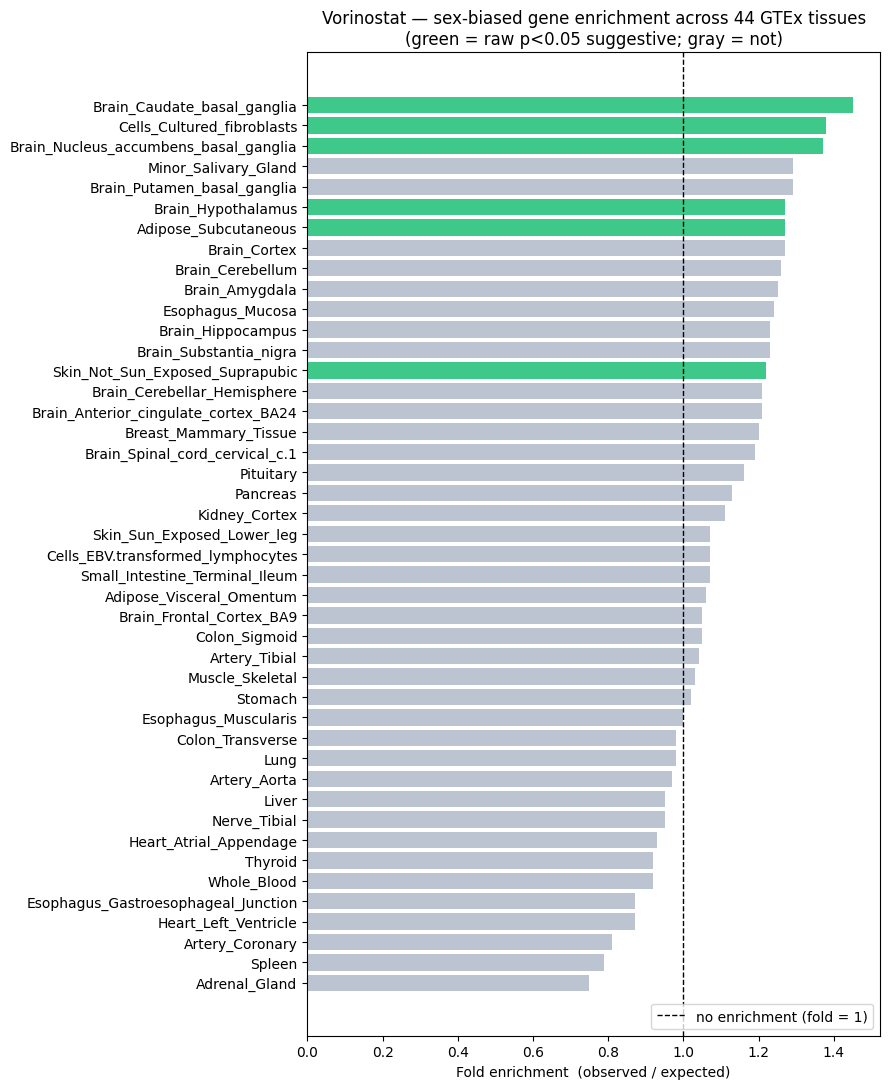

In [ ]:
import matplotlib.pyplot as plt

# Bar chart: 44 tissues by fold enrichment
plot_df = results_df.sort_values('fold', ascending=True)
colors = ['#3ec98a' if p<0.05 else '#bcc4d1' for p in plot_df['p_value']]

fig, ax = plt.subplots(figsize=(9, 11))
ax.barh(plot_df['tissue'], plot_df['fold'], color=colors)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='no enrichment (fold = 1)')
ax.set_xlabel('Fold enrichment  (observed / expected)')
ax.set_title('Vorinostat — sex-biased gene enrichment across 44 GTEx tissues\n'
             '(green = raw p<0.05 suggestive; gray = not)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('vorinostat_tissue_enrichment.png', dpi=150)
plt.show()

### Cell 25 - Downloading the experiment metadata

**What we do:** We download `siginfo_beta.txt`, a large (about 444 MB) file from CMAP/LINCS that describes every drug-treatment experiment (which drug, which cell line, and so on), then confirm it with `ls -lh`.

**Output:** The file saved successfully at about **444M**.

**Why it matters:** So far we have only looked at one drug (vorinostat). To scale up to many drugs, we need this metadata file that lists all the experiments, so we can find which experiments belong to which drugs and cell lines.

*Jargon:* "Metadata" is data about the data - here, the labels describing each experiment rather than the gene measurements themselves.

In [ ]:
# Pichhle hafte wala drug-experiment metadata file
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/siginfo_beta.txt

# Confirm
!ls -lh siginfo_beta.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  443M  100  443M    0     0  27.8M      0  0:00:15  0:00:15 --:--:-- 29.5M
-rw-r--r-- 1 root root 444M May 29 07:06 siginfo_beta.txt


### Cell 26 - Loading and filtering the experiments

**What we do:** We load the big metadata file into a table called `sig`, attach each experiment's donor sex and tissue (by joining with the `cell` table), then keep only the rows we care about: actual drug treatments (`trt_cp`) done in cell lines with a known donor sex (Male or Female).

**Output:** The full file has about **1.2 million** rows; after filtering we have **596,117** experiments (roughly 342k female, 254k male), covering about **32,917** drugs across **136** cell lines.

**Why it matters:** This filtered table is the foundation for the whole drug-screening step. We only want real drug experiments where we know the donor's sex, since the entire question is about sex differences.

*Jargon:* `trt_cp` = "treatment with a compound" (a drug). A "join/merge" attaches matching information from another table.

In [ ]:
# Load siginfo (siginfo aapke earlier 'cell' DataFrame ke saath jodna hai)
sig = pd.read_csv('siginfo_beta.txt', sep='\t')
print("siginfo shape:", sig.shape)

# Join: har signature ko donor_sex aur cell_lineage do
cell_small = cell[['cell_iname', 'donor_sex', 'cell_type', 'cell_lineage']]
sig = sig.merge(cell_small, on='cell_iname', how='left')

# Filter: drug treatments (trt_cp) + known sex
sig_known = sig[
    (sig['pert_type'] == 'trt_cp') &
    (sig['donor_sex'].isin(['M', 'F']))
].copy()

print("\nsig_known shape:", sig_known.shape)
print("Donor sex split:")
print(sig_known['donor_sex'].value_counts())
print("\nUnique drugs:", sig_known['cmap_name'].nunique())
print("Unique cell lines:", sig_known['cell_iname'].nunique())

/tmp/ipykernel_1183/2536836986.py:2: DtypeWarning: Columns (0,3,4,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  sig = pd.read_csv('siginfo_beta.txt', sep='\t')


siginfo shape: (1201944, 37)

sig_known shape: (596117, 40)
Donor sex split:
donor_sex
F    341977
M    254140
Name: count, dtype: int64

Unique drugs: 32917
Unique cell lines: 136


### Cell 27 - Choosing the top 50 drugs to study

**What we do:** For each drug, we count how many male and how many female cell lines it was tested in. We keep only drugs tested in at least 5 of each (so we have enough data for a fair comparison), then pick the 50 most-tested drugs and save them.

**Output:** About **2,408** drugs pass the "at least 5 male and 5 female" rule; we take the top 50 (led by selumetinib, vorinostat, tozasertib) and save them to `top50_drugs.csv`.

**Why it matters:** A sex-difference test is only trustworthy if a drug was tested in enough cell lines of both sexes. This step picks the drugs with the strongest, most balanced data to analyse next.

*Jargon:* A `pivot_table` reshapes data into a grid (here, drugs by sex). `nunique` counts how many distinct values there are.

In [ ]:
# Drug summary: har drug ko kitne male/female cell lines mein test kiya gaya
drug_summary = sig_known.pivot_table(
    index='cmap_name',
    columns='donor_sex',
    values='cell_iname',
    aggfunc='nunique',
    fill_value=0
)
drug_summary['total'] = drug_summary['F'] + drug_summary['M']

# Filter: >=5 male AND >=5 female cell lines
good_drugs = drug_summary[(drug_summary['M']>=5) & (drug_summary['F']>=5)].sort_values('total', ascending=False)
print(f"Drugs with >=5 male AND >=5 female cell lines: {good_drugs.shape[0]}")

# Top 50 — sab se zyada-tested
top50_drugs = good_drugs.head(50)
print(f"\nTop 15 of our chosen 50:")
print(top50_drugs.head(15).to_string())

# Save karें
top50_drugs.to_csv('top50_drugs.csv')
print(f"\nSaved: top50_drugs.csv  ({len(top50_drugs)} drugs)")

Drugs with >=5 male AND >=5 female cell lines: 2408

Top 15 of our chosen 50:
donor_sex      F   M  total
cmap_name                  
selumetinib   65  52    117
vorinostat    63  53    116
tozasertib    65  51    116
NVP-BEZ235    64  50    114
fostamatinib  62  49    111
bortezomib    59  49    108
olaparib      60  47    107
BI-2536       60  47    107
ABT-737       60  46    106
troglitazone  57  48    105
NVP-AUY922    57  46    103
calcitriol    55  47    102
AS-605240     56  46    102
vemurafenib   56  45    101
PI-103        55  45    100

Saved: top50_drugs.csv  (50 drugs)


### Cell 28 - Downloading the big gene-expression file (33 GB)

**What we do:** We download the main CMAP data file - the actual gene-expression measurements for drug experiments. It is very large (about 33 GB) and takes roughly 15 minutes, so the cell must run and wait. Then `ls -lh` confirms it.

**Output:** The download completes after about 15 minutes, leaving a **34G** file (`level5_beta_trt_cp_n720216x12328.gctx`).

**Why it matters:** Everything so far has been labels and metadata. This file holds the real numbers - how active each gene was in each experiment - which we need to actually measure sex differences for each drug.

*Jargon:* `.gctx` is a compact file format for large gene-expression matrices. GB = gigabytes (1 GB is about a billion bytes).

In [ ]:
# Bara CMAP data file (33 GB) — gene expression numbers
# 40-50 min lagега. Cell chalаें aur intezar karें.
!curl -O https://cmapreg.s3.amazonaws.com/galenAI/level5_beta_trt_cp_n720216x12328.gctx

# Confirm
!ls -lh level5_beta_trt_cp_n720216x12328.gctx

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 33.0G  100 33.0G    0     0  38.2M      0  0:14:46  0:14:46 --:--:-- 43.5M
-rw-r--r-- 1 root root 34G May 29 07:24 level5_beta_trt_cp_n720216x12328.gctx


### Cell 29 - Installing the reader tool and finding our experiments

**What we do:** We install `cmapPy`, a tool for reading the `.gctx` file. We read just the file's column labels (fast), then figure out which experiment IDs belong to our top 50 drugs, and check how many of those IDs are actually present in the big file.

**Output:** The file holds **720,216** experiment columns in total; we find **36,523** experiments for our 50 drugs, and confirm all 36,523 are present in the file.

**Why it matters:** The file is far too big to open all at once. Reading only the labels first lets us pinpoint exactly which columns we need, so later we can pull out just those instead of the whole 33 GB.

*Jargon:* A "signature"/`sig_id` is one experiment (one drug in one cell line). Reading `col_meta_only` grabs labels without the heavy data.

In [ ]:
!pip install cmapPy
from cmapPy.pandasGEXpress.parse import parse

gctx_file = 'level5_beta_trt_cp_n720216x12328.gctx'

# File ke column labels padhें (fast)
col_meta = parse(gctx_file, col_meta_only=True)
gctx_sigs = set(col_meta.index)
print(f"Signatures in gctx file: {len(gctx_sigs)}")

# Top 50 drugs ke saare signatures
top50_names = top50_drugs.index.tolist()
sig_for_top50 = sig_known[sig_known['cmap_name'].isin(top50_names)].copy()
print(f"Total experiments for top 50 drugs: {len(sig_for_top50)}")

# Verify: kitne sig_ids file mein hain?
valid_sigs = [s for s in sig_for_top50['sig_id'] if s in gctx_sigs]
print(f"Valid sig_ids in gctx file: {len(valid_sigs)} of {len(sig_for_top50)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 4.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


Signatures in gctx file: 720216
Total experiments for top 50 drugs: 36523
Valid sig_ids in gctx file: 36523 of 36523


### Cell 30 - (Attempt) Pulling out all the experiment data at once

**What we do:** This cell tries to read all 36,523 of our experiment columns from the big file in one go, into a single expression matrix.

**Output:** An error - `NameError: name 'valid_sigs' is not defined`.

**Why it matters:** The error simply means the notebook's memory had been reset (so the `valid_sigs` list from the earlier cell was lost) when this cell was run. It is a "re-run order" issue, not a problem with the analysis. The next cell fixes this by reloading everything needed, and the drug loop later reads each drug's columns one at a time instead of all at once.

*Jargon:* A `NameError` means Python was asked to use a variable that hadn't been created yet in the current session.

In [ ]:
# Extract saare 36,523 columns ek saath - 5-20 min lagега, patience
print(f"Extracting {len(valid_sigs)} signatures from 33 GB file — patience...")

all_data = parse(gctx_file, cid=valid_sigs)
expr_all = all_data.data_df

print(f"\n Expression matrix: {expr_all.shape}")
print(f"(rows = genes, columns = experiments)")
print(f"Memory: ~{expr_all.memory_usage().sum() / 1e9:.2f} GB")

NameError: name 'valid_sigs' is not defined

### Cell 31 - Checking everything we have downloaded

**What we do:** We list all files in the workspace with `ls -lh` to take stock of what we have.

**Output:** A file listing totalling about **34G**, including all the pieces we've gathered: `cellinfo_beta.txt`, `geneinfo_beta.txt`, the GTEx folder, `siginfo_beta.txt`, `top50_drugs.csv`, the big `.gctx` file, and the saved vorinostat result files.

**Why it matters:** It is a quick sanity check before the heavy analysis: every input file we need is present and has a sensible size.

In [ ]:
!ls -lh

total 34G
-rw-r--r-- 1 root root   38K May 29 06:37 cellinfo_beta.txt
drwx------ 5 root root  4.0K May 29 04:48 drive
-rw-r--r-- 1 root root  1.1M May 29 06:41 geneinfo_beta.txt
drwxr-xr-x 2  501 staff 4.0K May 21  2020 GTEx_Analysis_v8_sbgenes
-rw-r--r-- 1 root root   31M May 29 06:20 GTEx_Analysis_v8_sbgenes.tar.gz
-rw-r--r-- 1 root root   34G May 29 07:24 level5_beta_trt_cp_n720216x12328.gctx
drwxr-xr-x 1 root root  4.0K May 26 13:25 sample_data
-rw-r--r-- 1 root root  444M May 29 07:06 siginfo_beta.txt
-rw-r--r-- 1 root root  1003 May 29 07:08 top50_drugs.csv
-rw-r--r-- 1 root root  1.6M May 29 06:41 vorinostat_all_genes_results.csv
-rw-r--r-- 1 root root  3.4K May 29 07:00 vorinostat_tissue_enrichment.csv
-rw-r--r-- 1 root root  226K May 29 07:04 vorinostat_tissue_enrichment.png


### Cell 32 - Reloading everything in one place

**What we do:** This is a "recovery" cell that re-imports all the tools and reloads every piece of data we need in a single block: the metadata tables, the GTEx sex-biased gene library, the filtered experiments, the top 50 drugs, the gctx file labels, the CMAP-to-GTEx mapping, the gene universe, and the Entrez-to-Ensembl lookup.

**Output:** Confirmation lines (sig_known shape, gctx signatures, universe size) ending with `✅ All recovered!`.

**Why it matters:** If the notebook's memory is reset (which is common with very large files), running this one cell rebuilds everything the main drug loop needs - so we don't have to re-run every earlier cell one by one.

*Jargon:* "Recovered" here means all the variables are back in memory and ready to use.

In [ ]:
import pandas as pd
import numpy as np
from cmapPy.pandasGEXpress.parse import parse
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Metadata
cell = pd.read_csv('cellinfo_beta.txt', sep='\t')
genes_info = pd.read_csv('geneinfo_beta.txt', sep='\t')

# GTEx sex-biased gene library
sbg = pd.read_csv('GTEx_Analysis_v8_sbgenes/signif.sbgenes.txt', sep='\t')
sb_library = sbg.groupby('tissue')['gene'].apply(list).to_dict()
sb_library_clean = {t: [g.split('.')[0] for g in g_list] for t, g_list in sb_library.items()}

# siginfo + filter
sig = pd.read_csv('siginfo_beta.txt', sep='\t', low_memory=False)
cell_small = cell[['cell_iname', 'donor_sex', 'cell_type', 'cell_lineage']]
sig = sig.merge(cell_small, on='cell_iname', how='left')
sig_known = sig[(sig['pert_type']=='trt_cp') & (sig['donor_sex'].isin(['M','F']))].copy()
print(f"sig_known: {sig_known.shape}")

# Top 50 drugs
drug_summary = sig_known.pivot_table(index='cmap_name', columns='donor_sex',
                                      values='cell_iname', aggfunc='nunique', fill_value=0)
drug_summary['total'] = drug_summary['F'] + drug_summary['M']
good_drugs = drug_summary[(drug_summary['M']>=5)&(drug_summary['F']>=5)].sort_values('total', ascending=False)
top50_drugs = good_drugs.head(50)
top50_names = top50_drugs.index.tolist()
print(f"top50_drugs: {len(top50_drugs)}")

# gctx file
gctx_file = 'level5_beta_trt_cp_n720216x12328.gctx'
col_meta = parse(gctx_file, col_meta_only=True)
gctx_sigs = set(col_meta.index)
print(f"gctx signatures: {len(gctx_sigs)}")

# CMAP ↔ GTEx mapping
cmap_to_gtex = {
    'lung':['Lung'], 'breast':['Breast_Mammary_Tissue'],
    'skin':['Skin_Sun_Exposed_Lower_leg','Skin_Not_Sun_Exposed_Suprapubic'],
    'liver':['Liver'], 'kidney':['Kidney_Cortex'], 'stomach':['Stomach'],
    'pancreas':['Pancreas'],
    'large_intestine':['Colon_Sigmoid','Colon_Transverse'],
    'haematopoietic_and_lymphoid_tissue':['Whole_Blood','Spleen','Cells_EBV.transformed_lymphocytes'],
    'central_nervous_system':[t for t in sb_library.keys() if t.startswith('Brain_')],
}

# Universe of Ensembl IDs
universe_ensg = set(genes_info['ensembl_id'].dropna().unique())
print(f"Universe (Ensembl): {len(universe_ensg)}")

# Entrez → Ensembl lookup
gid_to_ensg = dict(zip(genes_info['gene_id'].astype(str), genes_info['ensembl_id']))

print("\n✅ All recovered!")

sig_known: (596117, 40)
top50_drugs: 50


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


gctx signatures: 720216
Universe (Ensembl): 12276

✅ All recovered!


### Cell 33 - The main analysis recipe (and a 3-drug test)

**What we do:** We define `analyze_drug`, a reusable function that does the whole analysis for one drug: pull that drug's experiments from the big file, compare gene activity between male and female cell lines (a Mann-Whitney test per gene), find the "strong" sex-difference genes, test those against every tissue's sex-biased genes, and assign a category (A, B, or C). Then we test the function on the first 3 drugs.

**Output:** Each test drug runs in ~20-40 seconds; selumetinib, vorinostat, and tozasertib all come back as **Category C** (no clear tissue match).

**Why it matters:** Running on just 3 drugs first is a smart check that the recipe works and is fast enough before we unleash it on all 50.

*Jargon:* Mann-Whitney is a test comparing two groups without assuming a bell-curve. Category A = matches its own tissue, B = matches a different tissue, C = no clear match.

In [ ]:
import time

def analyze_drug(drug_name):
    """For one drug: DE genes nikalो, har tissue mein enrichment test, category dें."""
    drug_sigs = sig_known[sig_known['cmap_name']==drug_name]
    all_ids = drug_sigs['sig_id'].tolist()
    valid_ids = [s for s in all_ids if s in gctx_sigs]
    if len(valid_ids) < 20: return None

    # Parse only this drug's columns (small, fast)
    drug_data = parse(gctx_file, cid=valid_ids)
    expr = drug_data.data_df

    sex_map = drug_sigs.set_index('sig_id')['donor_sex'].to_dict()
    m_cols = [s for s in expr.columns if sex_map.get(s)=='M']
    f_cols = [s for s in expr.columns if sex_map.get(s)=='F']
    if len(m_cols)<10 or len(f_cols)<10: return None

    m_expr = expr[m_cols].values
    f_expr = expr[f_cols].values

    # Mann-Whitney per gene
    p_vals, diffs = [], []
    for i in range(expr.shape[0]):
        try: _, p = mannwhitneyu(m_expr[i], f_expr[i], alternative='two-sided')
        except: p = 1.0
        p_vals.append(p)
        diffs.append(m_expr[i].mean() - f_expr[i].mean())

    de = pd.DataFrame({'gene_id': expr.index.astype(str), 'difference': diffs, 'p_value': p_vals})
    de['p_adj'] = multipletests(de['p_value'], method='fdr_bh')[1]
    strong = de[(de['p_adj']<0.05) & (de['difference'].abs()>0.5)].copy()
    strong['ensembl_id'] = strong['gene_id'].map(gid_to_ensg)
    strong_ensg = set(strong['ensembl_id'].dropna())

    drug_lineages = set(drug_sigs['cell_lineage'].dropna().unique()) - {'unknown'}
    matching_tissues = set()
    for lin in drug_lineages:
        if lin in cmap_to_gtex: matching_tissues.update(cmap_to_gtex[lin])

    # Fisher per tissue
    tres = []
    for tissue, genes in sb_library_clean.items():
        tissue_sb = set(genes) & universe_ensg
        if len(tissue_sb)<50: continue
        a = len(strong_ensg & tissue_sb)
        if a==0: continue
        b = len(strong_ensg - tissue_sb)
        c = len(tissue_sb - strong_ensg)
        d = len(universe_ensg) - a - b - c
        exp_ = len(strong_ensg)*len(tissue_sb)/len(universe_ensg)
        odds, p = fisher_exact([[a,b],[c,d]], alternative='greater')
        tres.append({'tissue':tissue, 'overlap':a, 'fold':a/exp_, 'p_value':p,
                     'in_lineage': tissue in matching_tissues})

    if not tres:
        return {'drug':drug_name, 'n_sigs':len(valid_ids), 'n_strong_de':len(strong_ensg),
                'category':'C', 'best_tissue':None, 'best_fold':None, 'best_p':None,
                'drug_lineages':'|'.join(drug_lineages)}

    tres_df = pd.DataFrame(tres).sort_values('p_value')
    tres_df['p_adj'] = multipletests(tres_df['p_value'], method='fdr_bh')[1]
    sig_t = tres_df[tres_df['p_adj']<0.05]

    if len(sig_t)==0:
        category, best = 'C', None
    else:
        match = sig_t[sig_t['in_lineage']]
        if len(match)>0: category, best = 'A', match.iloc[0]
        else:            category, best = 'B', sig_t.iloc[0]

    return {'drug':drug_name, 'n_sigs':len(valid_ids), 'n_strong_de':len(strong_ensg),
            'category':category,
            'best_tissue': best['tissue'] if best is not None else None,
            'best_fold': round(best['fold'],2) if best is not None else None,
            'best_p': best['p_adj'] if best is not None else None,
            'drug_lineages': '|'.join(drug_lineages)}


# Test on first 3 drugs
results = []
for i, drug_name in enumerate(top50_names[:3], 1):
    print(f"[{i}/3] Processing {drug_name}...", flush=True)
    t0 = time.time()
    r = analyze_drug(drug_name)
    if r:
        print(f"  → done in {time.time()-t0:.0f}s — Category {r['category']}, best tissue: {r['best_tissue']}", flush=True)
        results.append(r)

print("\n=== Test results ===")
print(pd.DataFrame(results).to_string(index=False))

[1/3] Processing selumetinib...


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


  → done in 19s — Category C, best tissue: None
[2/3] Processing vorinostat...


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


  → done in 37s — Category C, best tissue: None
[3/3] Processing tozasertib...


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


  → done in 18s — Category C, best tissue: None

=== Test results ===
       drug  n_sigs  n_strong_de category best_tissue best_fold best_p                                                                                                                                                                                                                                  drug_lineages
selumetinib     952           60        C        None      None   None                   bone|large_intestine|soft_tissue|breast|upper_aerodigestive_tract|central_nervous_system|endometrium|ovary|lung|cervix|skin|kidney|stomach|urinary_tract|pancreas|prostate|liver|placenta|haematopoietic_and_lymphoid_tissue
 vorinostat    2641          270        C        None      None   None bone|large_intestine|soft_tissue|breast|upper_aerodigestive_tract|central_nervous_system|endometrium|ovary|lung|cervix|skin|kidney|autonomic_ganglia|stomach|urinary_tract|pancreas|prostate|liver|placenta|haematopoietic_and_lymphoid_tissue


### Cell 34 - Running the analysis on all 50 drugs

**What we do:** We loop through all 50 drugs, run `analyze_drug` on each, print a one-line progress update per drug, and save the results to a CSV every 5 drugs (so a crash won't lose progress). At the end we print the category breakdown and list any Category A drugs.

**Output:** A progress line for each drug (most take ~15-40 seconds), then the breakdown: **49 drugs are Category C and 1 is Category A** (AS-605240, matching Liver). Results saved to `top50_drug_classification.csv`.

**Why it matters:** This is the heart of the project - the actual screen of 50 drugs for sex-specific, tissue-matched effects. The headline finding: only one drug (AS-605240) shows a same-tissue match.

*Jargon:* Saving every 5 drugs is a "checkpoint" so long runs survive interruptions.

In [ ]:
all_results = []
for i, drug_name in enumerate(top50_names, 1):
    t0 = time.time()
    r = analyze_drug(drug_name)
    if r:
        elapsed = time.time() - t0
        print(f"[{i:2}/50] {drug_name:30} → {elapsed:>3.0f}s · Cat {r['category']} · "
              f"{r['n_strong_de']} strong DE", flush=True)
        all_results.append(r)
        # Har 5 drugs ke baad save (kernel crash se bachao)
        if i % 5 == 0:
            pd.DataFrame(all_results).to_csv('top50_drug_classification.csv', index=False)

# Final save
results_df = pd.DataFrame(all_results)
results_df.to_csv('top50_drug_classification.csv', index=False)

print(f"\n=== Done! {len(results_df)} drugs analyzed ===")
print(f"\nCategory breakdown:")
print(results_df['category'].value_counts())

# Category A wale dekho (sab se interesting)
cat_a = results_df[results_df['category']=='A']
if len(cat_a) > 0:
    print(f"\nCategory A drugs (same-tissue match):")
    print(cat_a[['drug','best_tissue','best_fold','best_p']].to_string(index=False))

/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


[ 1/50] selumetinib                    →  19s · Cat C · 60 strong DE


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


[ 2/50] vorinostat                     →  20s · Cat C · 270 strong DE


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


...

[48/50] imatinib                       →  16s · Cat C · 0 strong DE


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


[49/50] thalidomide                    →  22s · Cat C · 0 strong DE


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


[50/50] crizotinib                     →  17s · Cat C · 22 strong DE

=== Done! 50 drugs analyzed ===

Category breakdown:
category
C    49
A     1
Name: count, dtype: int64

Category A drugs (same-tissue match):
     drug best_tissue  best_fold   best_p
AS-605240       Liver      28.42 0.024712


### Cell 35 - Summarising the 50-drug results

**What we do:** We reload the saved results file (so this works even if the long run was interrupted) and print a clear summary: the category breakdown, details of any Category A and Category B drugs, and some overall statistics.

**Output:** 50 drugs analysed; **49 Category C, 1 Category A** (AS-605240, Liver, fold 28.4), **0 Category B**. Stats: mean strong-DE genes per drug ~123, median 6, with 15 drugs showing 0 strong genes and 7 showing over 100.

**Why it matters:** This is the clean, reportable summary of the whole screen. The big takeaway: for almost all drugs, sex-difference effects don't line up with any specific tissue's sex-biased genes - AS-605240 is the lone standout worth a closer look.

*Jargon:* "DE genes" = differentially expressed genes (genes whose activity differs - here, between sexes). "Median" is the middle value.

In [ ]:
# Saved results se load karें (defense — agar kernel issue ho)
df = pd.read_csv('top50_drug_classification.csv')
print(f"Drugs analyzed: {len(df)}\n")

# Category breakdown
print("=== Category breakdown ===")
print(df['category'].value_counts())

# Category A — sab se interesting
cat_a = df[df['category']=='A']
print(f"\n=== Category A (same-tissue match): {len(cat_a)} drugs ===")
if len(cat_a) > 0:
    print(cat_a[['drug','n_strong_de','best_tissue','best_fold','best_p','drug_lineages']].to_string(index=False))

# Category B
cat_b = df[df['category']=='B']
print(f"\n=== Category B (cross-tissue): {len(cat_b)} drugs ===")
if len(cat_b) > 0:
    print(cat_b[['drug','n_strong_de','best_tissue','best_fold','best_p']].to_string(index=False))

# Stats
print(f"\n=== Stats ===")
print(f"Mean strong DE genes per drug: {df['n_strong_de'].mean():.0f}")
print(f"Median: {df['n_strong_de'].median():.0f}")
print(f"Drugs with 0 strong DE: {(df['n_strong_de']==0).sum()}")
print(f"Drugs with >100 strong DE: {(df['n_strong_de']>100).sum()}")

Drugs analyzed: 50

=== Category breakdown ===
category
C    49
A     1
Name: count, dtype: int64

=== Category A (same-tissue match): 1 drugs ===
     drug  n_strong_de best_tissue  best_fold   best_p                                                                                                                                                                                                       drug_lineages
AS-605240            2       Liver      28.42 0.024712 bone|large_intestine|soft_tissue|breast|upper_aerodigestive_tract|central_nervous_system|endometrium|ovary|lung|cervix|skin|kidney|stomach|urinary_tract|pancreas|prostate|liver|haematopoietic_and_lymphoid_tissue

=== Category B (cross-tissue): 0 drugs ===

=== Stats ===
Mean strong DE genes per drug: 123
Median: 6
Drugs with 0 strong DE: 15
Drugs with >100 strong DE: 7


### Cell 36 - Charting the 50 drugs

**What we do:** We make a horizontal bar chart of all 50 drugs, ranked by how many strong sex-difference genes each one has. Bars are coloured by category (green for A, yellow for B, gray for C), with a log scale on the x-axis and a dashed line at 100 genes. The chart is saved as a PNG.

**Output:** A chart titled "Top 50 drugs - sex-difference signal across cell lines (Cat A: 1, Cat B: 0, Cat C: 49)", plus a saved file `top50_drugs_strong_de.png`.

**Why it matters:** The chart shows at a glance that drugs vary hugely in how many sex-difference genes they have (from 0 to thousands), while the category colouring reminds us that having many such genes still rarely produces a clean tissue match.

*Jargon:* A "log scale" squeezes a very wide range of values onto one axis so both small and large counts are visible.

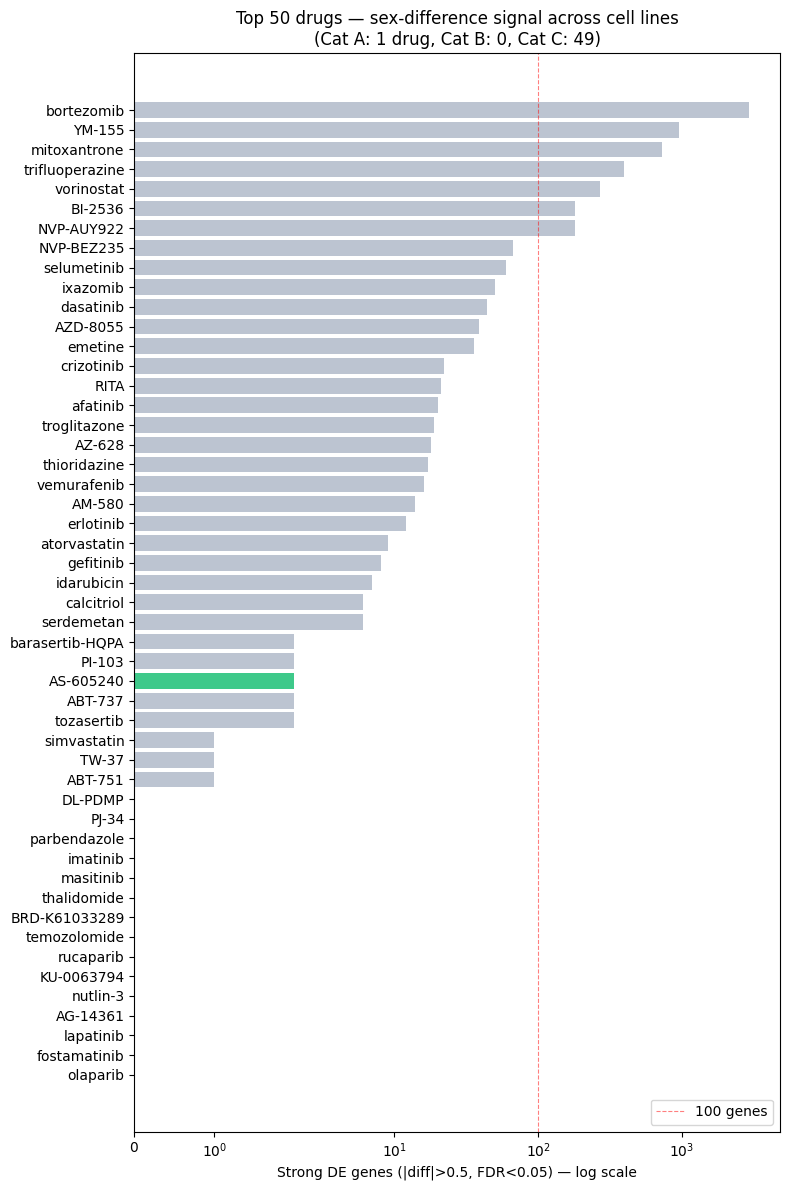


Saved: top50_drugs_strong_de.png
Saved: top50_drug_classification.csv


In [ ]:
# Bar chart: drugs ranked by strong DE count
import matplotlib.pyplot as plt

df_sorted = df.sort_values('n_strong_de', ascending=True)
colors = ['#3ec98a' if c=='A' else ('#ffce72' if c=='B' else '#bcc4d1') for c in df_sorted['category']]

fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(df_sorted['drug'], df_sorted['n_strong_de'], color=colors)
ax.set_xscale('symlog')
ax.set_xlabel('Strong DE genes (|diff|>0.5, FDR<0.05) — log scale')
ax.set_title(f'Top 50 drugs — sex-difference signal across cell lines\n'
             f'(Cat A: 1 drug, Cat B: 0, Cat C: 49)')
ax.axvline(100, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='100 genes')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('top50_drugs_strong_de.png', dpi=150)
plt.show()

print("\nSaved: top50_drugs_strong_de.png")
print("Saved: top50_drug_classification.csv")

### Cell 37 - Backing up the results to Google Drive

**What we do:** We copy the four result files (the drug classification CSV and chart, and the vorinostat enrichment CSV and chart) into Google Drive using `shutil.copy`, then print a confirmation.

**Output:** `✅ Backed up to Drive`.

**Why it matters:** The Colab workspace is temporary - it gets wiped when the session ends. Copying the results to Google Drive keeps them safe so they can be reused or shared later without re-running the whole (very long) pipeline.

*Jargon:* `shutil.copy` copies a file from one place to another. `/content/drive/MyDrive/` is the folder that links to your Google Drive.

In [ ]:
# Drive mein backup
import shutil
shutil.copy('top50_drug_classification.csv', '/content/drive/MyDrive/')
shutil.copy('top50_drugs_strong_de.png', '/content/drive/MyDrive/')
shutil.copy('vorinostat_tissue_enrichment.csv', '/content/drive/MyDrive/')
shutil.copy('vorinostat_tissue_enrichment.png', '/content/drive/MyDrive/')
print("✅ Backed up to Drive")

✅ Backed up to Drive
